In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [47]:
df = pd.read_csv('parkinsons_updrs.data')


In [48]:
df

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5870,42,61,0,142.7900,22.485,33.485,0.00406,0.000031,0.00167,0.00168,...,0.160,0.00973,0.01133,0.01549,0.02920,0.025137,22.369,0.64215,0.55314,0.21367
5871,42,61,0,149.8400,21.988,32.988,0.00297,0.000025,0.00119,0.00147,...,0.215,0.01052,0.01277,0.01904,0.03157,0.011927,22.886,0.52598,0.56518,0.12621
5872,42,61,0,156.8200,21.495,32.495,0.00349,0.000025,0.00152,0.00187,...,0.244,0.01371,0.01456,0.01877,0.04112,0.017701,25.065,0.47792,0.57888,0.14157
5873,42,61,0,163.7300,21.007,32.007,0.00281,0.000020,0.00128,0.00151,...,0.131,0.00693,0.00870,0.01307,0.02078,0.007984,24.422,0.56865,0.56327,0.14204


| Column | Description |
|---|---|
| `subject#` | Patient ID (1–42). Just an identifier, not useful for ML |
| `age` | Age of the patient in years |
| `sex` | Gender — 0 = Male, 1 = Female |
| `test_time` | Number of days since the study started |
| `motor_UPDRS` | Severity of physical/motor Parkinson's symptoms |
| `total_UPDRS` | Overall Parkinson's severity score **(our target)** |
| `Jitter(*)` | Measures variation in voice frequency (pitch instability) |
| `Shimmer(*)` | Measures variation in voice amplitude (loudness instability) |
| `NHR` | Noise-to-Harmonic Ratio — higher means more noise in voice |
| `HNR` | Harmonic-to-Noise Ratio — higher means cleaner voice |
| `RPDE` | Measures how chaotic/repetitive the voice signal is |
| `DFA` | Measures self-similarity in voice signal over time |
| `PPE` | Measures pitch irregularity — key sign of Parkinson's |

In [49]:
print('Columns:')
print(df.columns.tolist())

Columns:
['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR            5875

In [51]:
df.describe()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,0.317787,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,0.465656,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,0.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,0.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,0.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,1.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,1.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


In [52]:
df.isnull().any()


subject#         False
age              False
sex              False
test_time        False
motor_UPDRS      False
total_UPDRS      False
Jitter(%)        False
Jitter(Abs)      False
Jitter:RAP       False
Jitter:PPQ5      False
Jitter:DDP       False
Shimmer          False
Shimmer(dB)      False
Shimmer:APQ3     False
Shimmer:APQ5     False
Shimmer:APQ11    False
Shimmer:DDA      False
NHR              False
HNR              False
RPDE             False
DFA              False
PPE              False
dtype: bool

In [53]:
print(f'Total Patients: {df["subject#"].nunique()}')
print(f'Age Range: {df["age"].min()} to {df["age"].max()} years')
print(f'Gender Distribution:')
print(df['sex'].value_counts().rename({0: 'Male', 1: 'Female'}))

Total Patients: 42
Age Range: 36 to 85 years
Gender Distribution:
sex
Male      4008
Female    1867
Name: count, dtype: int64


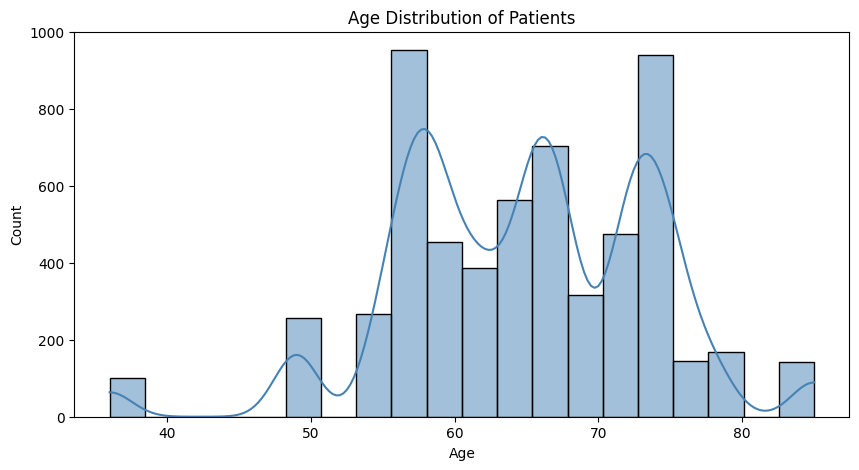

In [54]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

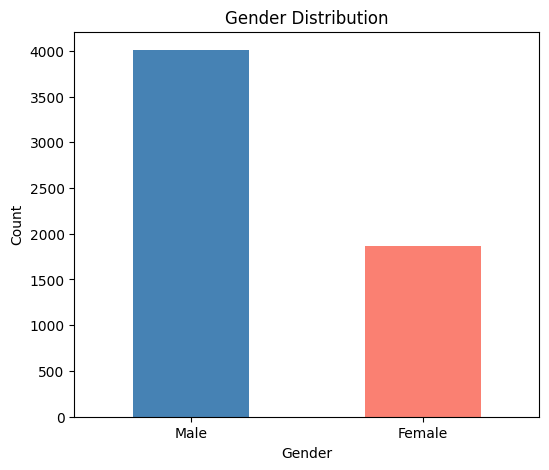

In [55]:
plt.figure(figsize=(6, 5))
df['sex'].value_counts().rename({0: 'Male', 1: 'Female'}).plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [56]:
print('total_UPDRS Statistics:')
df['total_UPDRS'].describe()

total_UPDRS Statistics:


count    5875.000000
mean       29.018942
std        10.700283
min         7.000000
25%        21.371000
50%        27.576000
75%        36.399000
max        54.992000
Name: total_UPDRS, dtype: float64

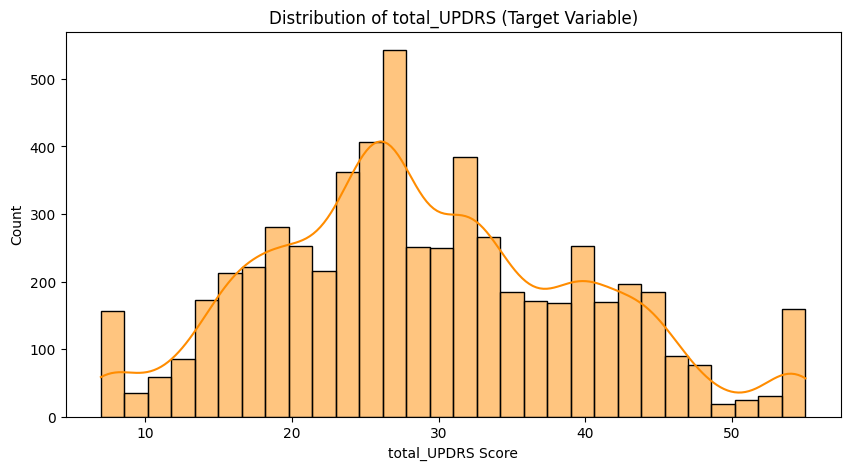

In [57]:
plt.figure(figsize=(10, 5))
sns.histplot(df['total_UPDRS'], bins=30, kde=True, color='darkorange')
plt.title('Distribution of total_UPDRS (Target Variable)')
plt.xlabel('total_UPDRS Score')
plt.ylabel('Count')
plt.show()

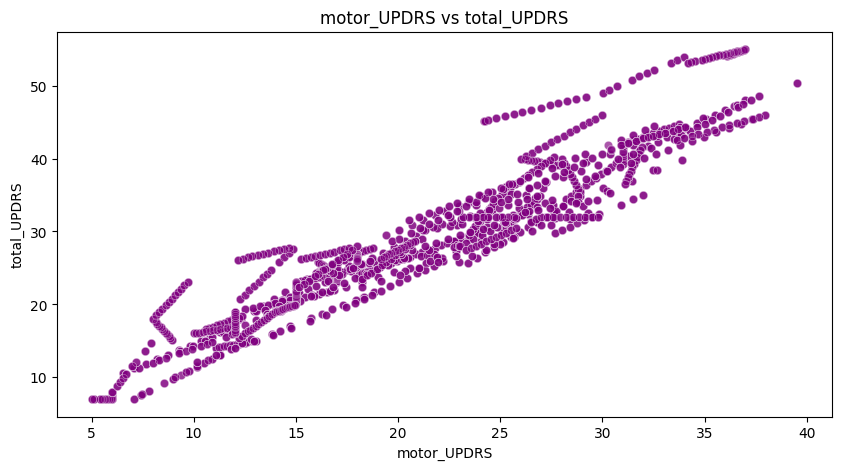

In [58]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['motor_UPDRS'], y=df['total_UPDRS'], alpha=0.3, color='purple')
plt.title('motor_UPDRS vs total_UPDRS')
plt.xlabel('motor_UPDRS')
plt.ylabel('total_UPDRS')
plt.show()

---
##  Feature Distributions

We plot the distribution of all voice features to understand their spread:

- **Jitter features** → Measure pitch/frequency instability. Parkinson's patients have higher jitter
- **Shimmer features** → Measure loudness instability. Higher shimmer = more vocal tremor
- **NHR** → High value means more noise in voice (bad sign)
- **HNR** → High value means cleaner voice (good sign)
- **RPDE, DFA, PPE** → Nonlinear complexity features. Abnormal values indicate voice disorder

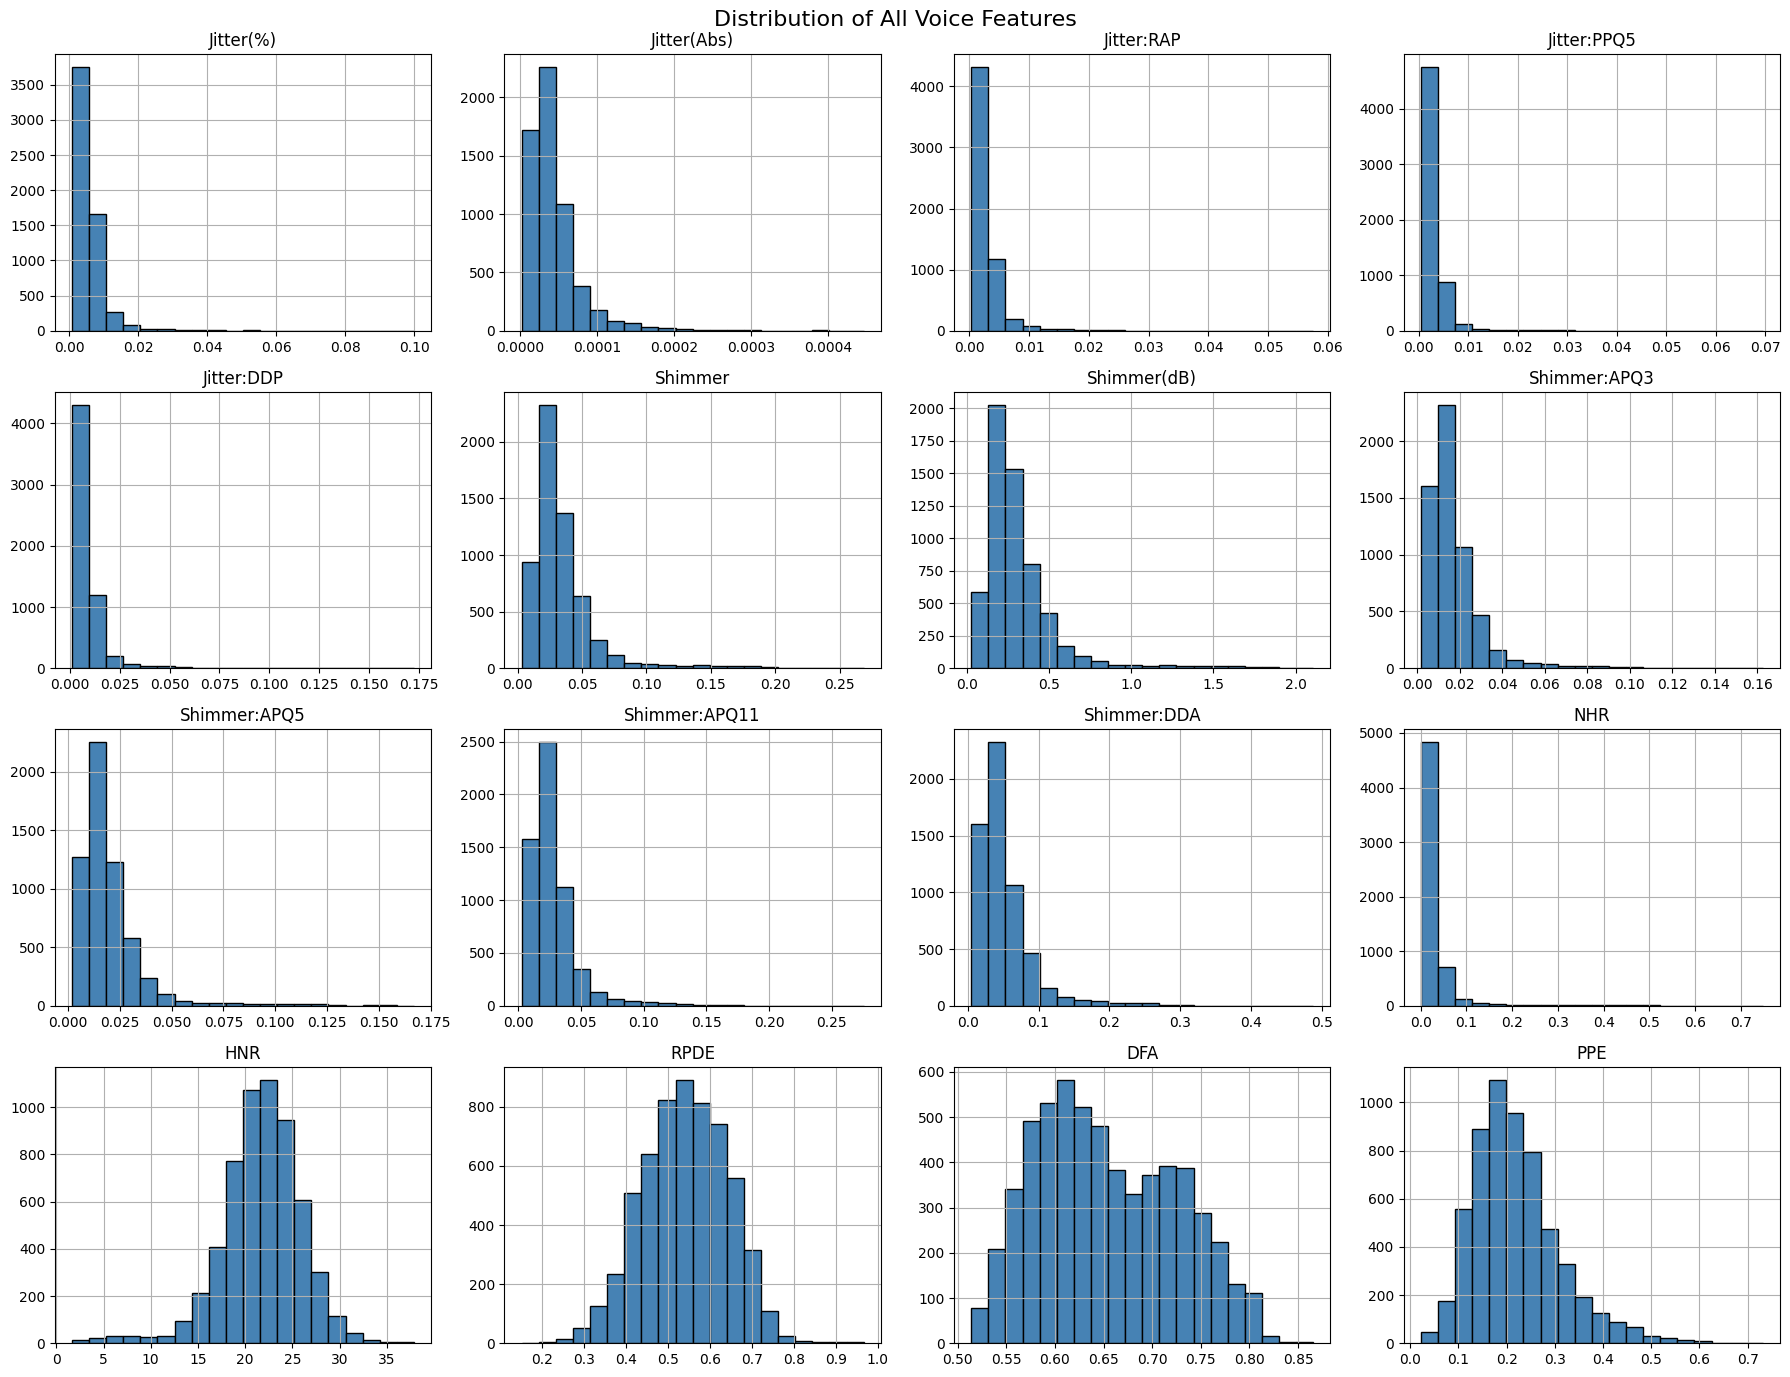

In [59]:
voice_features = ['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
                  'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
                 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

df[voice_features].hist(bins=20, figsize=(18, 14), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of All Voice Features', fontsize=16)
plt.tight_layout()
plt.show()

---
##  Correlation Heatmap

A correlation heatmap shows how strongly two columns are related:
- Value close to **+1** → strong positive relationship (both increase together)
- Value close to **-1** → strong negative relationship (one increases, other decreases)
- Value close to **0** → no relationship

This helps us:
- Find which features are most useful for prediction
- Find features that are too similar to each other (multicollinearity)

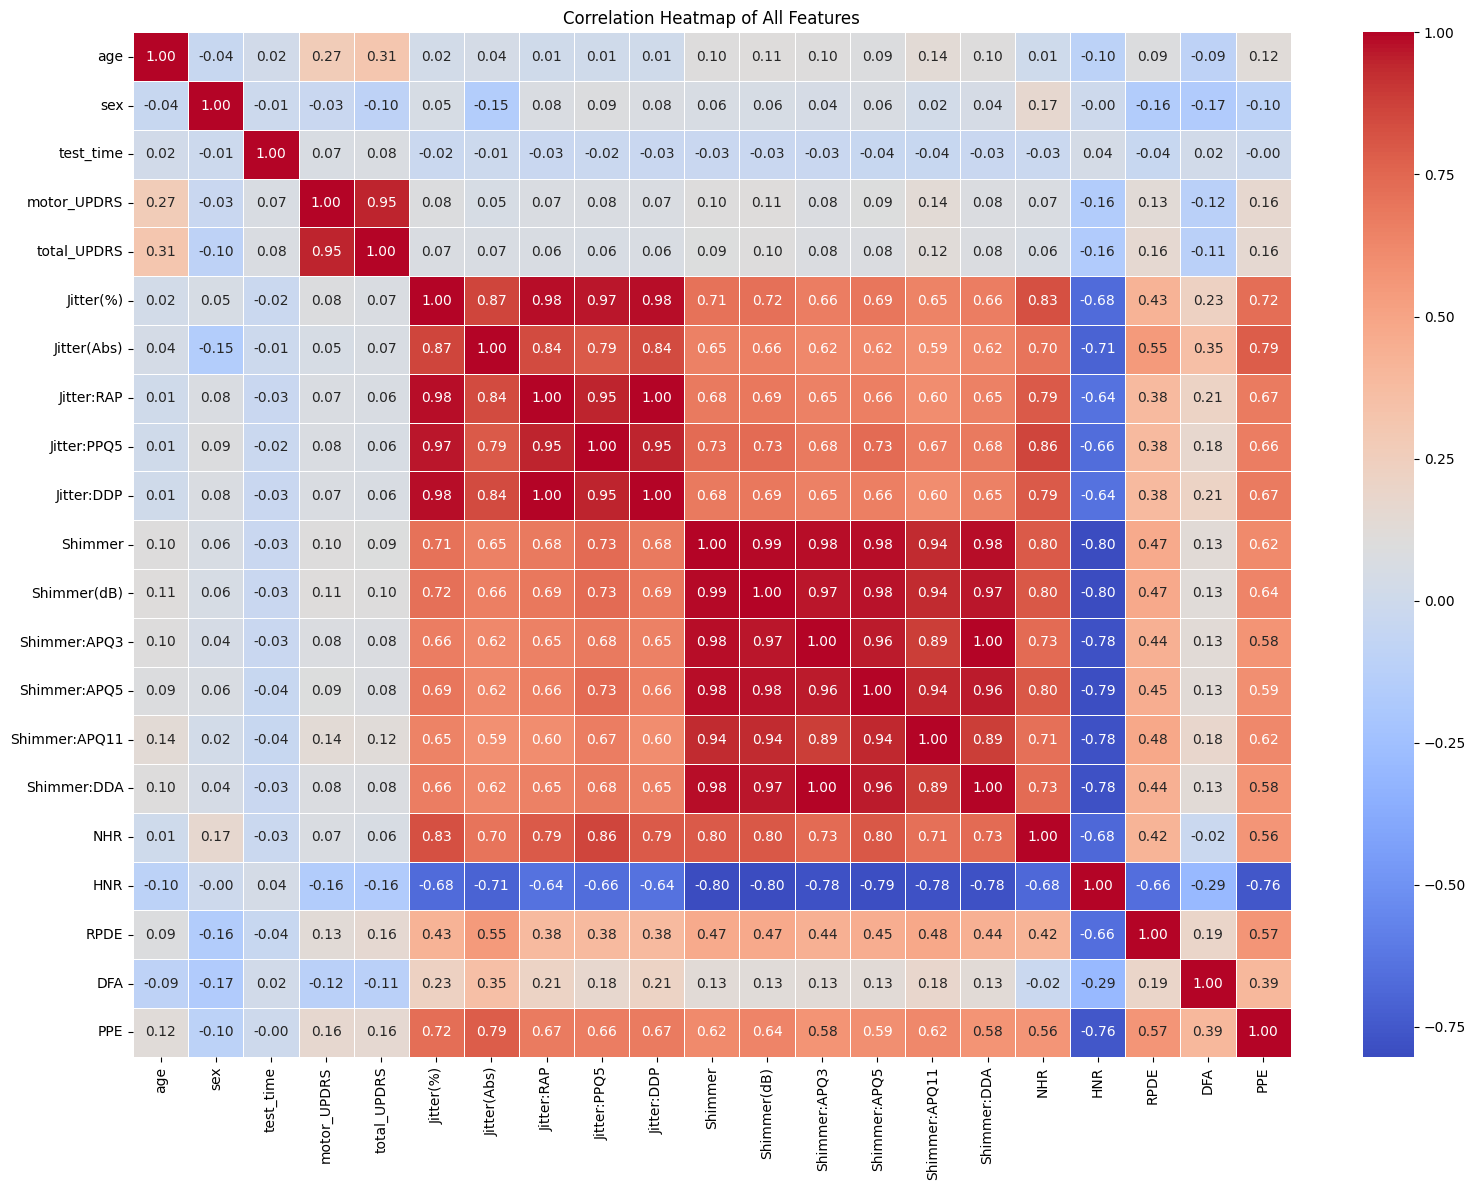

In [60]:
df_corr = df.drop(columns=['subject#'])

plt.figure(figsize=(16, 12))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

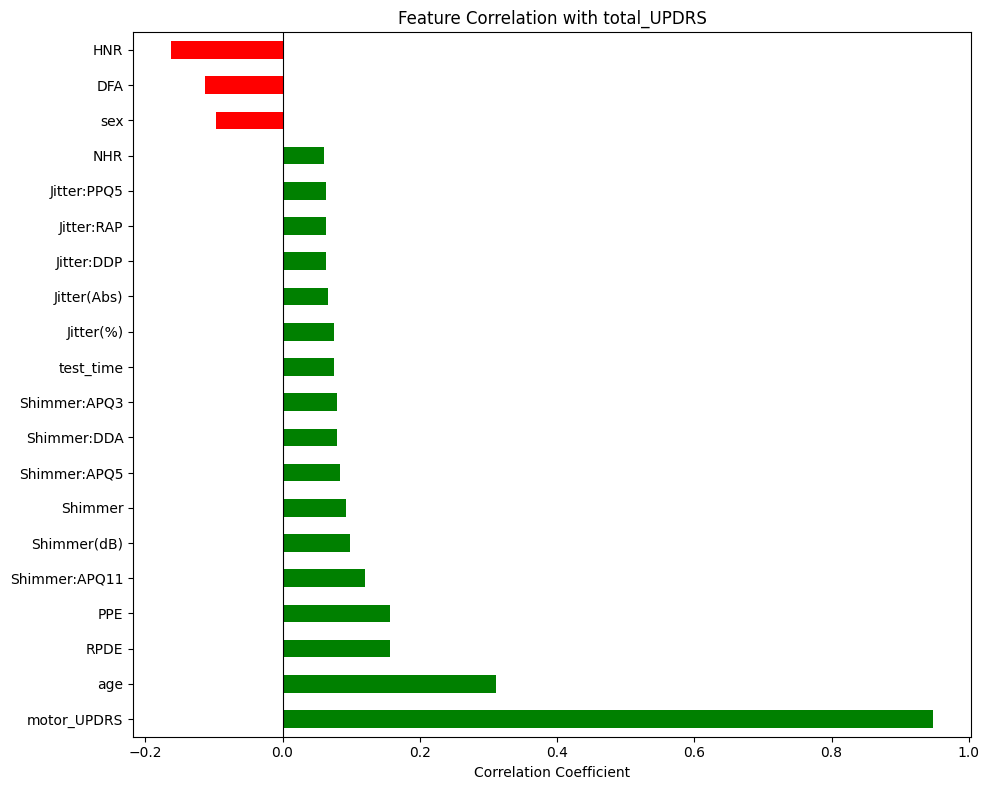


Top Positively Correlated Features:
motor_UPDRS      0.947231
age              0.310290
RPDE             0.156897
PPE              0.156195
Shimmer:APQ11    0.120838
Name: total_UPDRS, dtype: float64

Top Negatively Correlated Features:
sex   -0.096559
DFA   -0.113475
HNR   -0.162117
Name: total_UPDRS, dtype: float64


In [61]:
corr_target = df_corr.corr()['total_UPDRS'].drop('total_UPDRS').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_target.plot(kind='barh', color=['green' if x > 0 else 'red' for x in corr_target])
plt.title('Feature Correlation with total_UPDRS')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nTop Positively Correlated Features:')
print(corr_target.head(5))
print('\nTop Negatively Correlated Features:')
print(corr_target.tail(3))

---
##  Outlier Detection (Boxplots)

Boxplots help detect **outliers** — extreme values that are far from normal range.
- The **box** shows where 50% of data lies (Q1 to Q3)
- The **line in middle** is the median
- **Dots outside the whiskers** are outliers

Outliers in medical data are common and important — they may represent severe cases.

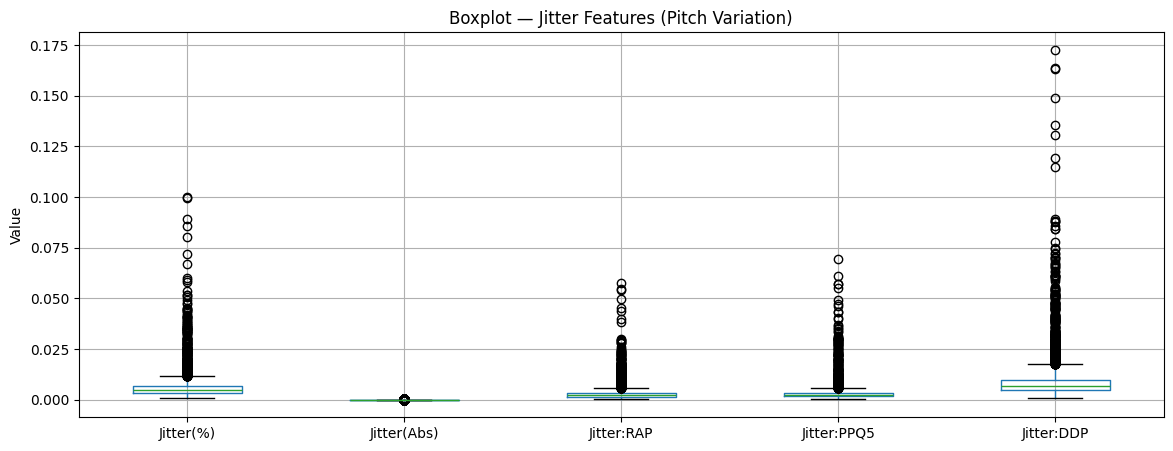

In [62]:
jitter_columns = ['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP']

plt.figure(figsize=(14, 5))
df[jitter_columns].boxplot()
plt.title('Boxplot — Jitter Features (Pitch Variation)')
plt.ylabel('Value')
plt.show()

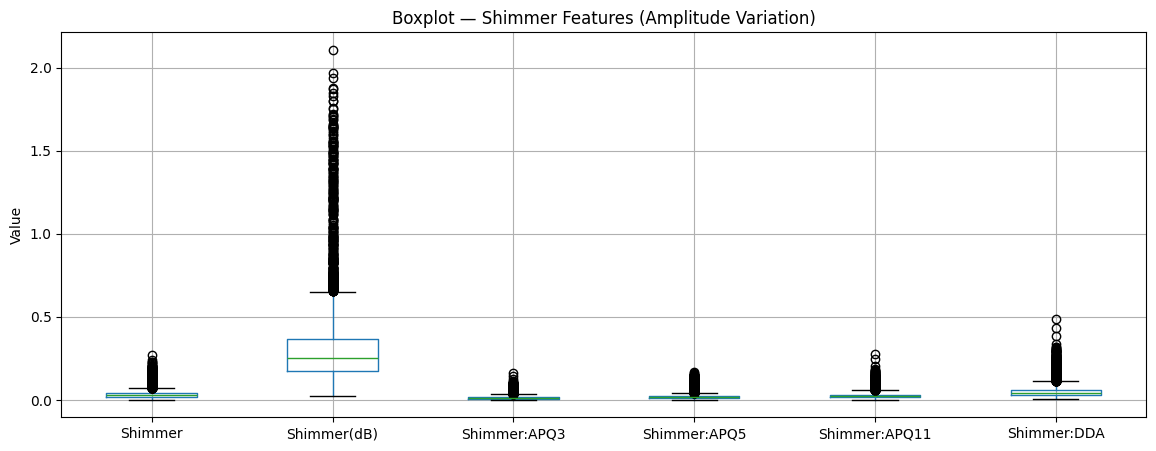

In [63]:
shimmer_columns = ['Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA']

plt.figure(figsize=(14, 5))
df[shimmer_columns].boxplot()
plt.title('Boxplot — Shimmer Features (Amplitude Variation)')
plt.ylabel('Value')
plt.show()

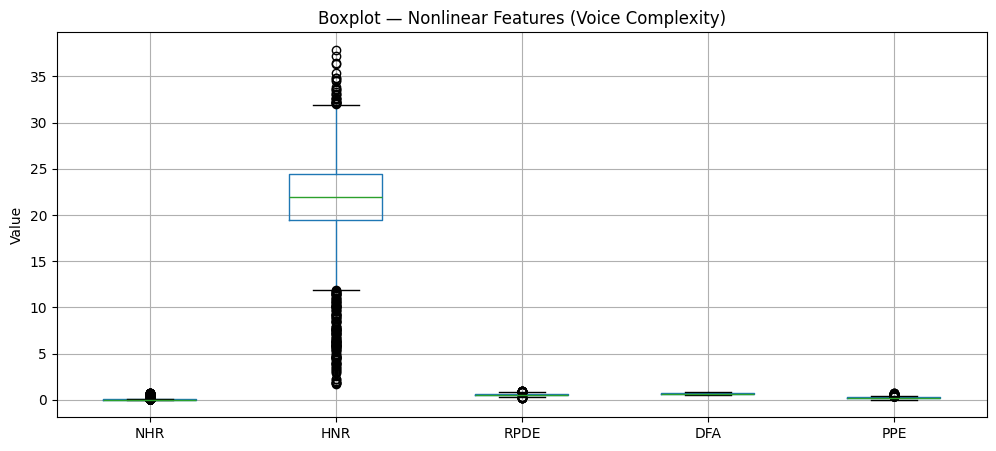

In [64]:
nonlinear_columns = ['NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

plt.figure(figsize=(12, 5))
df[nonlinear_columns].boxplot()
plt.title('Boxplot — Nonlinear Features (Voice Complexity)')
plt.ylabel('Value')
plt.show()

---
## Patient-wise UPDRS Trend Over Time

- `test_time` = number of days since the study started
- We plot how each patient's `total_UPDRS` score changes over time
- Since Parkinson's is progressive, we expect scores to **increase over time**
- This confirms the dataset captures real disease progression

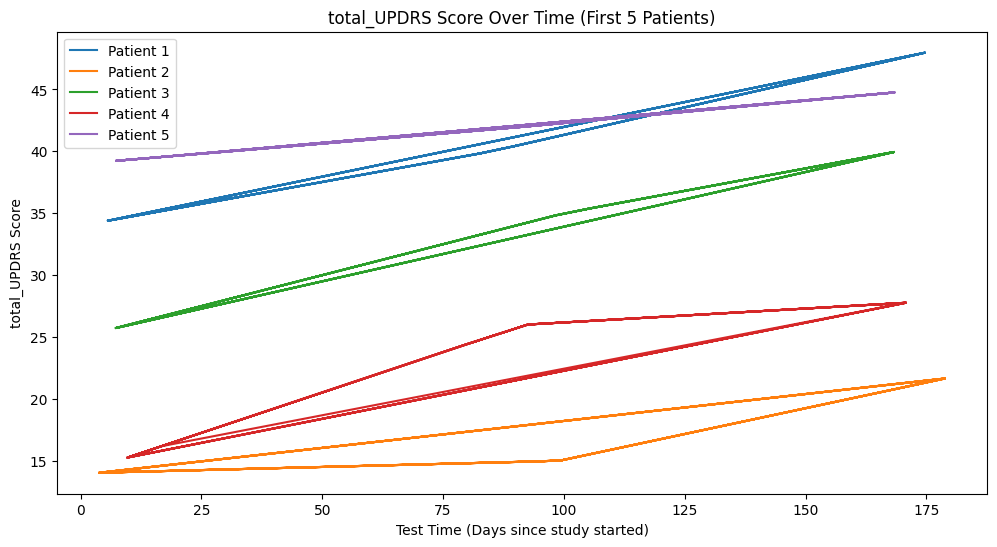

In [65]:
plt.figure(figsize=(12, 6))
for patient_id in range(1, 6):
    patient_data = df[df['subject#'] == patient_id]
    plt.plot(patient_data['test_time'], patient_data['total_UPDRS'], label=f'Patient {patient_id}')

plt.title('total_UPDRS Score Over Time (First 5 Patients)')
plt.xlabel('Test Time (Days since study started)')
plt.ylabel('total_UPDRS Score')
plt.legend()
plt.show()

In [66]:
print('         EDA SUMMARY')
print('=' * 50)
print(f'Total Records       : {df.shape[0]}')
print(f'Total Features      : {df.shape[1]}')
print(f'Total Patients      : {df["subject#"].nunique()}')
print(f'Missing Values      : {df.isnull().sum().sum()}')
print(f'Age Range           : {df["age"].min()} - {df["age"].max()} years')
print(f'total_UPDRS Range   : {df["total_UPDRS"].min():.2f} - {df["total_UPDRS"].max():.2f}')
print(f'total_UPDRS Mean    : {df["total_UPDRS"].mean():.2f}')


         EDA SUMMARY
Total Records       : 5875
Total Features      : 22
Total Patients      : 42
Missing Values      : 0
Age Range           : 36 - 85 years
total_UPDRS Range   : 7.00 - 54.99
total_UPDRS Mean    : 29.02
